# explanatory data analysis

# imports

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import scipy.stats as stats
from pandas.plotting import autocorrelation_plot


db_path = '../../database/financial_data.duckdb'

In [2]:
%matplotlib inline

In [3]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',100)

# connection

In [4]:
conn = duckdb.connect(db_path)

In [5]:
def query(sql):
    return conn.execute(sql).df()

In [6]:
conn.execute("show tables").df()

,name
0,bybit_crypto
1,clean_bybit_crypto
2,clean_yahoo_stocks
3,dim_assets
4,dim_date
5,dim_interval
6,fact_price_history
7,gold_feature_statistics
8,gold_financial_analytics
9,gold_ml_features


In [7]:
conn.execute("describe gold_ml_features").df()

,column_name,column_type,null,key,default,extra
0,asset_symbol,VARCHAR,YES,None,None,None
1,asset_class,VARCHAR,YES,None,None,None
2,exchange,VARCHAR,YES,None,None,None
3,interval,VARCHAR,YES,None,None,None
4,date,TIMESTAMP,YES,None,None,None
5,open,DOUBLE,YES,None,None,None
6,high,DOUBLE,YES,None,None,None
7,low,DOUBLE,YES,None,None,None
8,close,DOUBLE,YES,None,None,None
9,volume,DOUBLE,YES,None,None,None


In [8]:
conn.execute("select asset_class, count(*) as total_rows,count(distinct asset_symbol) as unique_assets from gold_ml_features group by asset_class").df()

,asset_class,total_rows,unique_assets
0,Crypto,488699,11
1,Stock,44520,6


In [9]:
conn.execute("select distinct asset_class, asset_symbol from gold_ml_features").df()

,asset_class,asset_symbol
0,Crypto,SOL
1,Stock,GOOGL
2,Crypto,1000PEPE
3,Crypto,ADA
4,Crypto,LTC
5,Crypto,DOGE
6,Stock,META
7,Crypto,DOT
8,Crypto,DYDX
9,Stock,AAPL


# utils

In [10]:
ASSET = 'AAPL'
INTERVAL = '1h'

# dataframe

In [11]:
df = query(f"SELECT * FROM gold_ml_features WHERE asset_symbol = '{ASSET}' AND interval = '{INTERVAL}' ORDER BY date ASC")

In [12]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# in returns_1p , etc , the p stands for period for its individual interval

In [13]:
df.head()

,asset_symbol,asset_class,exchange,interval,open,high,low,close,volume,daily_volatility,sma_7,sma_30,rsi_14,macd,macd_signal,macd_histogram,roc_10,roc_20,stoch_k,stoch_d,ema_12,ema_26,ema_50,ema_200,sma_50,sma_100,sma_200,bb_upper,bb_middle,bb_lower,bb_width,bb_percentage,atr_14,obv,vwap,volume_sma_20,volume_ratio,returns_1p,returns_5p,returns_10p,returns_20p,log_returns,hl_ratio,close_position,prev_close,prev_volume,prev_high,prev_low
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-05-13 16:30:00,AAPL,Stock,Yahoo Finance,1h,186.289993,186.929993,186.250000,186.658600,8098301.0,0.679993,184.748228,183.362917,73.207505,1.048488,0.821489,0.226999,1.885100,2.175111,94.345968,92.559982,184.588121,183.539634,181.587905,175.015465,182.424482,176.540636,173.057098,186.492298,183.895325,181.298353,2.824403,1.032018,0.934391,100238880.0,184.465847,6489191.35,1.247968,0.001979,0.020327,0.018851,0.021751,0.001977,0.003643,0.600889,186.289993,7602808.0,186.500000,185.779999
2024-05-13 17:30:00,AAPL,Stock,Yahoo Finance,1h,186.660004,186.949997,186.369995,186.650101,5453676.0,0.580002,185.306813,183.533920,73.117205,1.135310,0.884253,0.251057,2.167660,2.055876,93.778076,94.439465,184.905349,183.770039,181.786422,175.131232,182.703506,176.744437,173.140165,186.897318,184.083325,181.269333,3.057303,0.956074,0.909077,94785204.0,184.599602,6515007.35,0.837094,-0.000046,0.019946,0.021677,0.020559,-0.000046,0.003107,0.482939,186.658600,8098301.0,186.929993,186.250000
2024-05-13 18:30:00,AAPL,Stock,Yahoo Finance,1h,186.659897,187.100006,186.559998,186.989899,6516486.0,0.540009,185.885369,183.681584,74.472907,1.217502,0.950903,0.266599,2.466507,2.325650,97.784559,95.302868,185.226049,184.008547,181.990480,175.249229,182.985304,176.950416,173.222515,187.306911,184.295820,181.284729,3.267672,0.947359,0.882715,101301690.0,184.761802,6579785.75,0.990380,0.001821,0.007006,0.024665,0.023257,0.001819,0.002888,0.796101,186.650101,5453676.0,186.949997,186.369995
2024-05-13 19:30:00,AAPL,Stock,Yahoo Finance,1h,186.985001,187.029999,186.070007,186.285004,9250536.0,0.959991,186.354656,183.811884,66.932183,1.211792,1.003081,0.208711,2.132734,1.561992,83.601565,91.721400,185.388965,184.177173,182.158893,175.359038,183.248004,177.144866,173.302340,187.541093,184.439070,181.337047,3.363737,0.797537,0.888235,92051154.0,184.931447,6560574.80,1.410019,-0.003770,0.001963,0.021327,0.015620,-0.003777,0.005153,0.223957,186.989899,6516486.0,187.100006,186.559998
2024-05-14 13:30:00,AAPL,Stock,Yahoo Finance,1h,187.649994,188.300003,186.550003,187.009995,14754549.0,1.750000,186.543370,183.957717,70.266822,1.251342,1.052733,0.198609,2.336647,1.835110,79.092238,86.826121,185.638354,184.387012,182.349132,175.474968,183.526404,177.346466,173.386365,187.879145,184.607570,181.335995,3.544356,0.867166,0.968718,106805703.0,185.405440,7010610.80,2.104602,0.003892,0.003865,0.023366,0.018351,0.003884,0.009358,0.262852,186.285004,9250536.0,187.029999,186.070007


In [14]:
df.isnull().sum

<bound method DataFrame.sum of                      asset_symbol  asset_class  exchange  interval   open  \
date                                                                        
2024-05-13 16:30:00         False        False     False     False  False   
2024-05-13 17:30:00         False        False     False     False  False   
2024-05-13 18:30:00         False        False     False     False  False   
2024-05-13 19:30:00         False        False     False     False  False   
2024-05-14 13:30:00         False        False     False     False  False   
2024-05-14 14:30:00         False        False     False     False  False   
2024-05-14 15:30:00         False        False     False     False  False   
2024-05-14 16:30:00         False        False     False     False  False   
2024-05-14 17:30:00         False        False     False     False  False   
2024-05-14 18:30:00         False        False     False     False  False   
2024-05-14 19:30:00         False        Fals

In [15]:
df.describe()

,open,high,low,close,volume,daily_volatility,sma_7,sma_30,rsi_14,macd,macd_signal,macd_histogram,roc_10,roc_20,stoch_k,stoch_d,ema_12,ema_26,ema_50,ema_200,sma_50,sma_100,sma_200,bb_upper,bb_middle,bb_lower,bb_width,bb_percentage,atr_14,obv,vwap,volume_sma_20,volume_ratio,returns_1p,returns_5p,returns_10p,returns_20p,log_returns,hl_ratio,close_position,prev_close,prev_volume,prev_high,prev_low
count,3473.000000,3473.000000,3473.000000,3473.000000,3.473000e+03,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3.473000e+03,3473.000000,3.473000e+03,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3473.000000,3.473000e+03,3473.000000,3473.000000
mean,234.791521,235.647828,233.966956,234.826607,5.481243e+06,1.680871,234.734037,234.377061,52.389052,0.213181,0.211211,0.001970,0.156109,0.314008,54.010918,54.019958,234.655915,234.442735,234.088127,232.017371,234.081734,233.358736,231.952337,239.119458,234.530657,229.941856,3.967155,0.539663,1.766305,5.036993e+08,234.607220,5.487857e+06,1.012147,0.000152,0.000770,0.001561,0.003140,0.000130,0.007251,0.514034,234.795956,5.482480e+06,235.617220,233.936426
std,25.300060,25.284569,25.285817,25.291124,4.402487e+06,1.245270,25.226369,25.005077,13.916081,1.737216,1.633821,0.523830,2.097174,3.080112,30.346455,28.493377,25.131900,24.958232,24.750038,24.386401,24.848521,24.703962,24.834992,25.218618,25.099333,25.357139,2.864949,0.338085,0.647405,1.364739e+08,25.166026,2.392072e+06,0.650530,0.006582,0.014798,0.020972,0.030801,0.006590,0.005762,0.296597,25.285422,4.402480e+06,25.279704,25.279967
min,172.179001,173.440002,169.210098,172.770004,0.000000e+00,0.244995,176.253830,183.362917,12.045578,-9.909394,-8.937071,-2.375600,-13.843334,-21.313525,0.000000,1.039051,179.458269,183.539634,181.587905,175.015465,182.424482,176.540636,173.057098,186.492298,180.822404,167.851293,0.492501,-0.526629,0.686741,9.205115e+07,179.413137,1.705615e+06,0.000000,-0.081125,-0.092900,-0.138433,-0.213135,-0.084605,0.001205,0.000000,172.770004,0.000000e+00,173.440002,169.210098
25%,214.610001,215.380005,213.919998,214.585297,2.969148e+06,0.919998,214.450557,214.106039,42.458238,-0.786185,-0.784981,-0.294015,-0.909130,-1.249134,25.769149,27.608376,214.235915,214.314985,215.153282,212.626271,214.087435,215.029246,213.033374,219.625637,214.255493,210.518035,2.166410,0.265064,1.392922,4.198040e+08,214.390966,4.071062e+06,0.612682,-0.002202,-0.005973,-0.009091,-0.012491,-0.002205,0.003911,0.256422,214.551407,2.969148e+06,215.369995,213.910095
50%,230.740005,231.649994,230.104996,230.729996,4.127268e+06,1.320007,230.910856,230.849647,52.798141,0.318889,0.328245,0.010931,0.173896,0.391649,58.037184,56.991024,231.041874,230.828855,229.972956,228.314096,230.401684,230.222964,229.118927,235.141960,230.931127,226.190597,3.210778,0.585291,1.672675,4.924232e+08,231.024099,4.905449e+06,0.804666,0.000044,0.001093,0.001739,0.003916,0.000044,0.005627,0.515367,230.729706,4.129270e+06,231.634995,230.095001
75%,255.884995,256.660004,255.009995,255.910004,6.402020e+06,2.014999,255.930001,255.121828,62.738216,1.240796,1.216349,0.283062,1.262576,1.892123,81.886676,80.524034,255.782483,255.161013,254.619491,256.212327,254.481244,254.639347,255.833113,260.443743,255.482996,250.776011,4.760644,0.807908,1.972992,6.063482e+08,255.643289,6.087522e+06,1.165375,0.002467,0.007657,0.012626,0.018921,0.002464,0.008644,0.780098,255.889999,6.404020e+06,256.640015,254.970001
max,293.769989,294.760010,293.100006,293.785004,6.005223e+07,19.520004,293.002568,289.781265,89.515826,5.862387,4.774119,3.493478,13.609100,14.801175,100.000000,99.236057,291.995553,289.945123,286.064247,273.974427,285.787300,278.987065,275.542766,295.587560,291.413649,287.239738,27.301377,1.485160,6.611305,

In [16]:
df.describe(include="object")

,asset_symbol,asset_class,exchange,interval
count,3473,3473,3473,3473
unique,1,1,1,1
top,AAPL,Stock,Yahoo Finance,1h
freq,3473,3473,3473,3473


In [17]:
correlations = df.corr(numeric_only=True)['close'].sort_values(ascending=False)
correlations.head(10)

close         1.000000
high          0.999364
low           0.999343
open          0.998803
prev_close    0.998258
prev_high     0.997620
prev_low      0.997619
sma_7         0.996754
ema_12        0.995463
vwap          0.993769
Name: close, dtype: float64

# price vs rsi

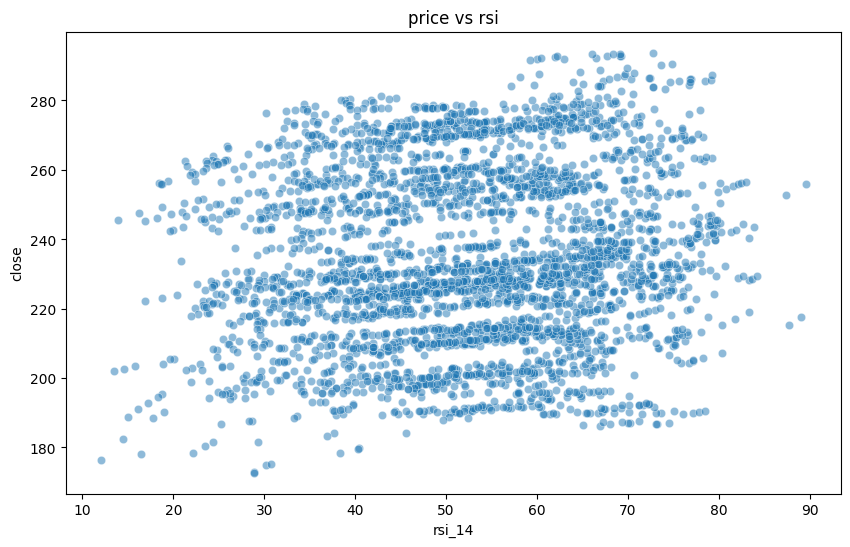

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['rsi_14'],y=df['close'],alpha=0.5)
plt.title("price vs rsi")
plt.show()

In [19]:
df['interval'].unique()

array(['1h'], dtype=object)

# missing value analysis

In [20]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values:")
missing

Columns with missing values:


,Missing Count,Missing %


# target value analysis

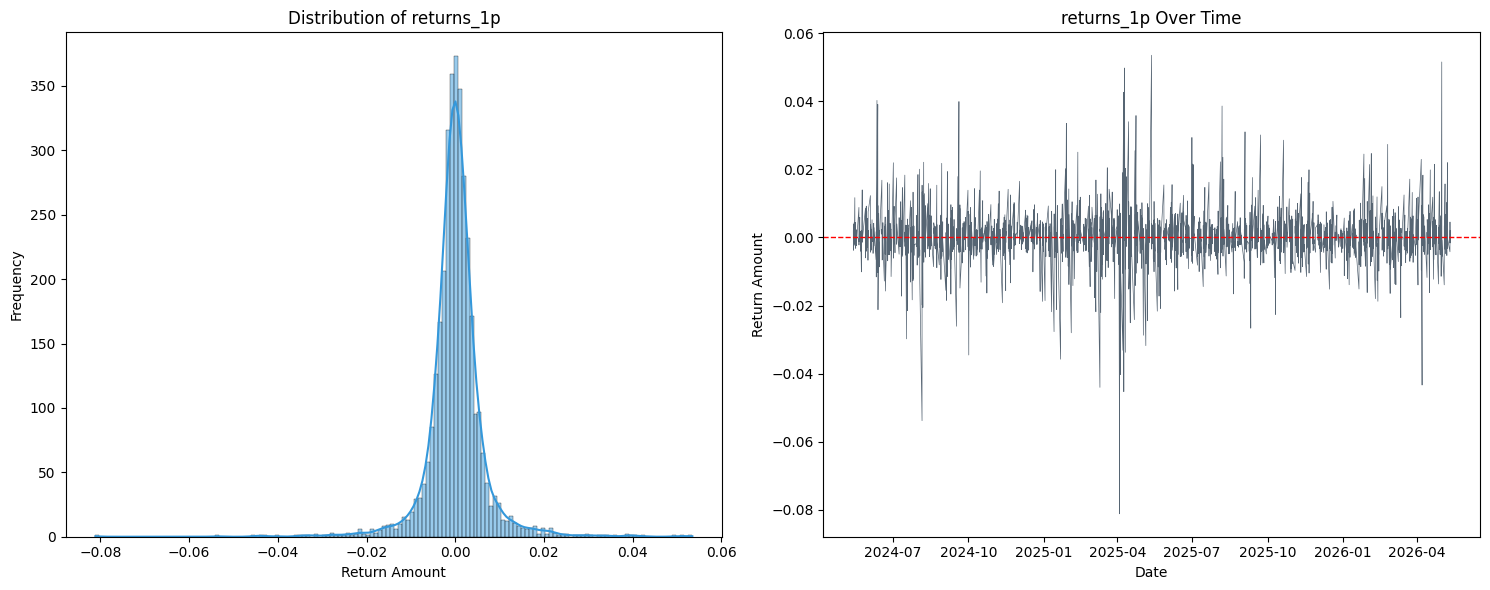

--- RETURNS_1P STATISTICS ---
Mean Return:  0.000152
Min Return:   -0.081125
Max Return:   0.053491
------------------------------
Standard Deviation (Volatility): 0.006582
Skewness: -0.31 (0 is symmetrical. Negative = bigger crashes, positive = bigger pumps)
Kurtosis: 18.67 (>3 means 'fat tails' - extreme events )


In [21]:
target_col = 'returns_1p'
target_data = df[target_col].dropna()


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(target_data, bins=150, kde=True, ax=axes[0], color='#3498db')
axes[0].set_title(f"Distribution of {target_col}")
axes[0].set_xlabel("Return Amount")
axes[0].set_ylabel("Frequency")

axes[1].plot(df.index, df[target_col], color='#2c3e50', alpha=0.8, linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title(f"{target_col} Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Return Amount")

plt.tight_layout()
plt.show()

print(f"--- {target_col.upper()} STATISTICS ---")
print(f"Mean Return:  {target_data.mean():.6f}")
print(f"Min Return:   {target_data.min():.6f}")
print(f"Max Return:   {target_data.max():.6f}")
print("-" * 30)

print(f"Standard Deviation (Volatility): {target_data.std():.6f}")
print(f"Skewness: {target_data.skew():.2f} (0 is symmetrical. Negative = bigger crashes, positive = bigger pumps)")
print(f"Kurtosis: {target_data.kurtosis():.2f} (>3 means 'fat tails' - extreme events )")

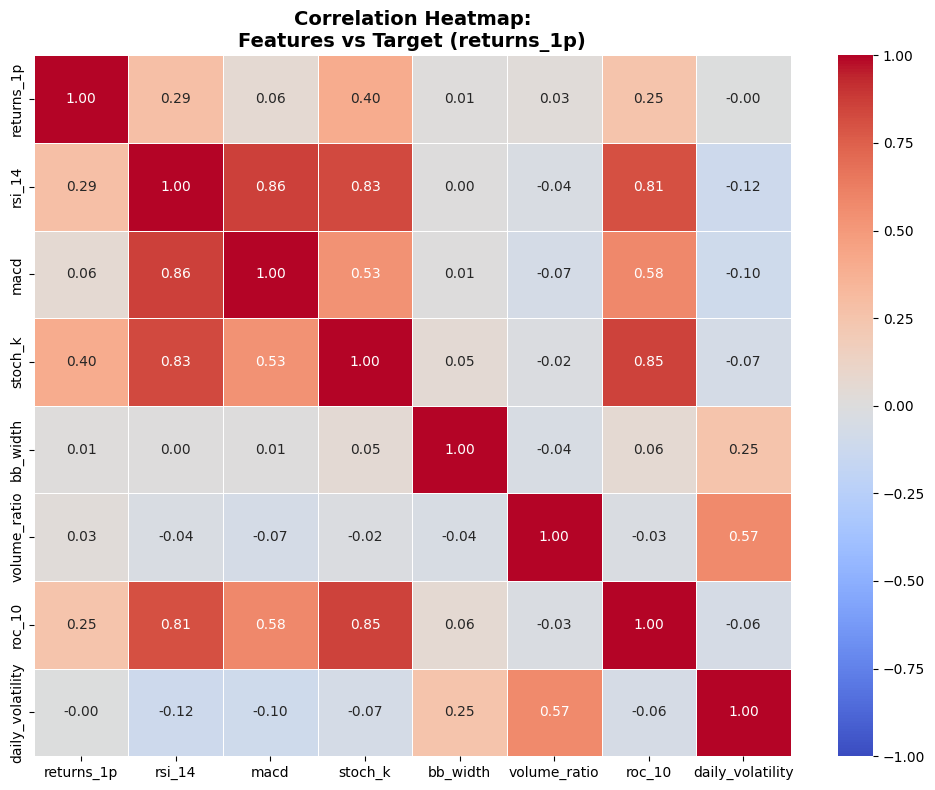


--- Features Most Correlated with returns_1p ---
stoch_k             0.400529
rsi_14              0.287754
roc_10              0.253104
macd                0.055275
volume_ratio        0.025539
bb_width            0.012228
daily_volatility   -0.002786
Name: returns_1p, dtype: float64


In [22]:
features = [
    'returns_1p', 'rsi_14', 'macd', 'stoch_k', 'bb_width', 
    'volume_ratio', 'roc_10', 'daily_volatility'
]

corr_matrix = df[features].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap:\nFeatures vs Target (returns_1p)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = corr_matrix['returns_1p'].drop('returns_1p').sort_values(ascending=False)
print("\n--- Features Most Correlated with returns_1p ---")
print(target_corr)

# autocorrelation of returns

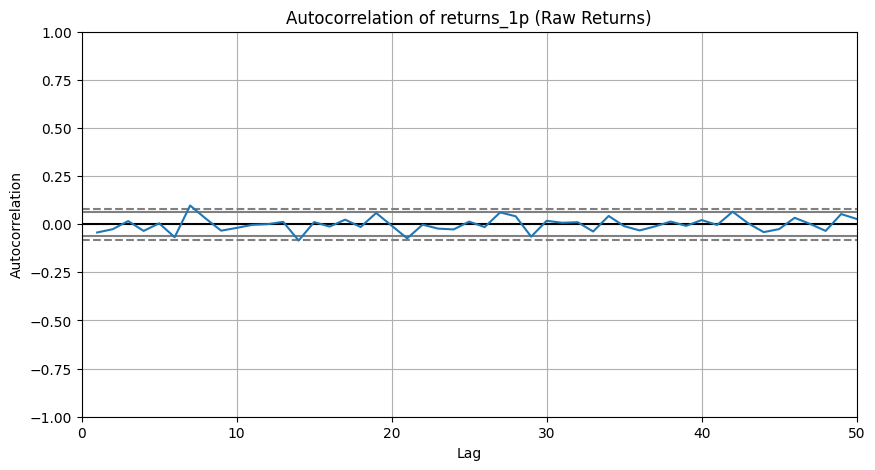

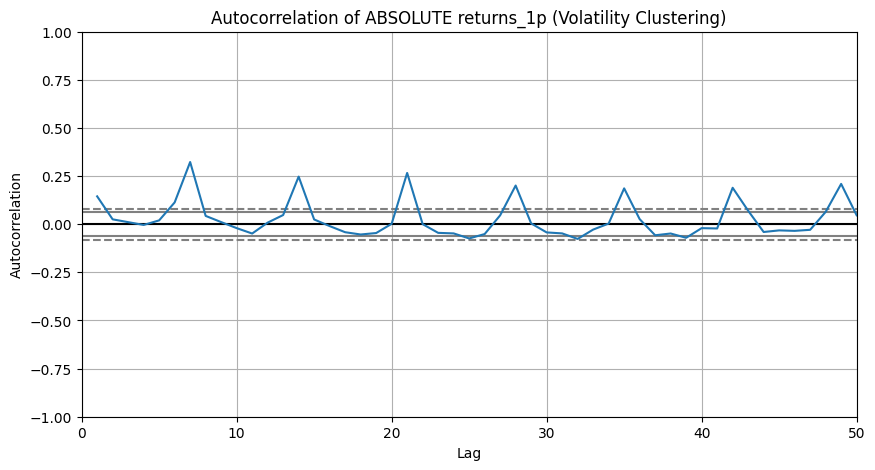

In [23]:
plt.figure(figsize=(10, 5))
autocorrelation_plot(target_data[:1000]) 
plt.xlim(0, 50)
plt.title(f"Autocorrelation of {target_col} (Raw Returns)")
plt.show()

plt.figure(figsize=(10, 5))
autocorrelation_plot(target_data.abs()[:1000])
plt.xlim(0, 50)
plt.title(f"Autocorrelation of ABSOLUTE {target_col} (Volatility Clustering)")
plt.show()

# small mistake in pipeline when generating indicators returns its hardcoded so in her ejust checking the differences of 24hrs return or the 1hr return (done fixed)

In [24]:
df['check_1h_return'] = df['close'].pct_change(1)
df['check_24h_return'] = df['close'].pct_change(24)

comparison = df[['close', 'check_1h_return', 'check_24h_return', 'returns_1p']].dropna().head(10)

print(comparison)

                          close  check_1h_return  check_24h_return  returns_1p
date                                                                          
2024-05-16 19:30:00  189.899994         0.000079          0.017365    0.000079
2024-05-17 13:30:00  190.150101         0.001317          0.018752    0.001317
2024-05-17 14:30:00  189.697006        -0.002383          0.014477   -0.002383
2024-05-17 15:30:00  189.789993         0.000490          0.018815    0.000490
2024-05-17 16:30:00  189.684998        -0.000553          0.014304   -0.000553
2024-05-17 17:30:00  189.679993        -0.000026          0.014440   -0.000026
2024-05-17 18:30:00  190.108307         0.002258          0.017710    0.002258
2024-05-17 19:30:00  189.929993        -0.000938          0.018228   -0.000938
2024-05-20 13:30:00  191.604996         0.008819          0.022824    0.008819
2024-05-20 14:30:00  191.179993        -0.002218          0.018296   -0.002218


In [25]:
conn.close()